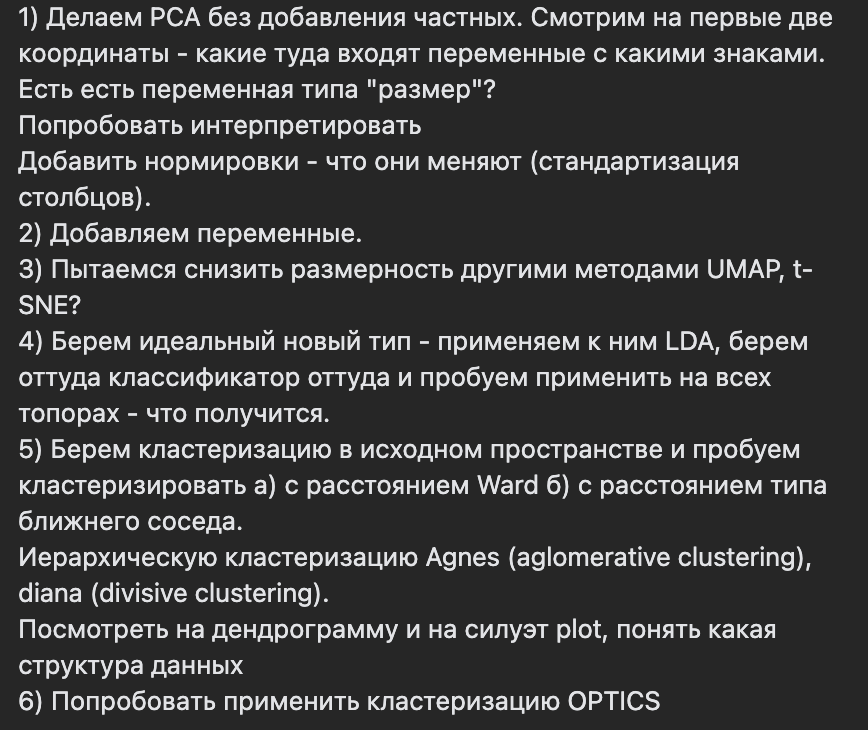

# Dataframe с категориальными данными

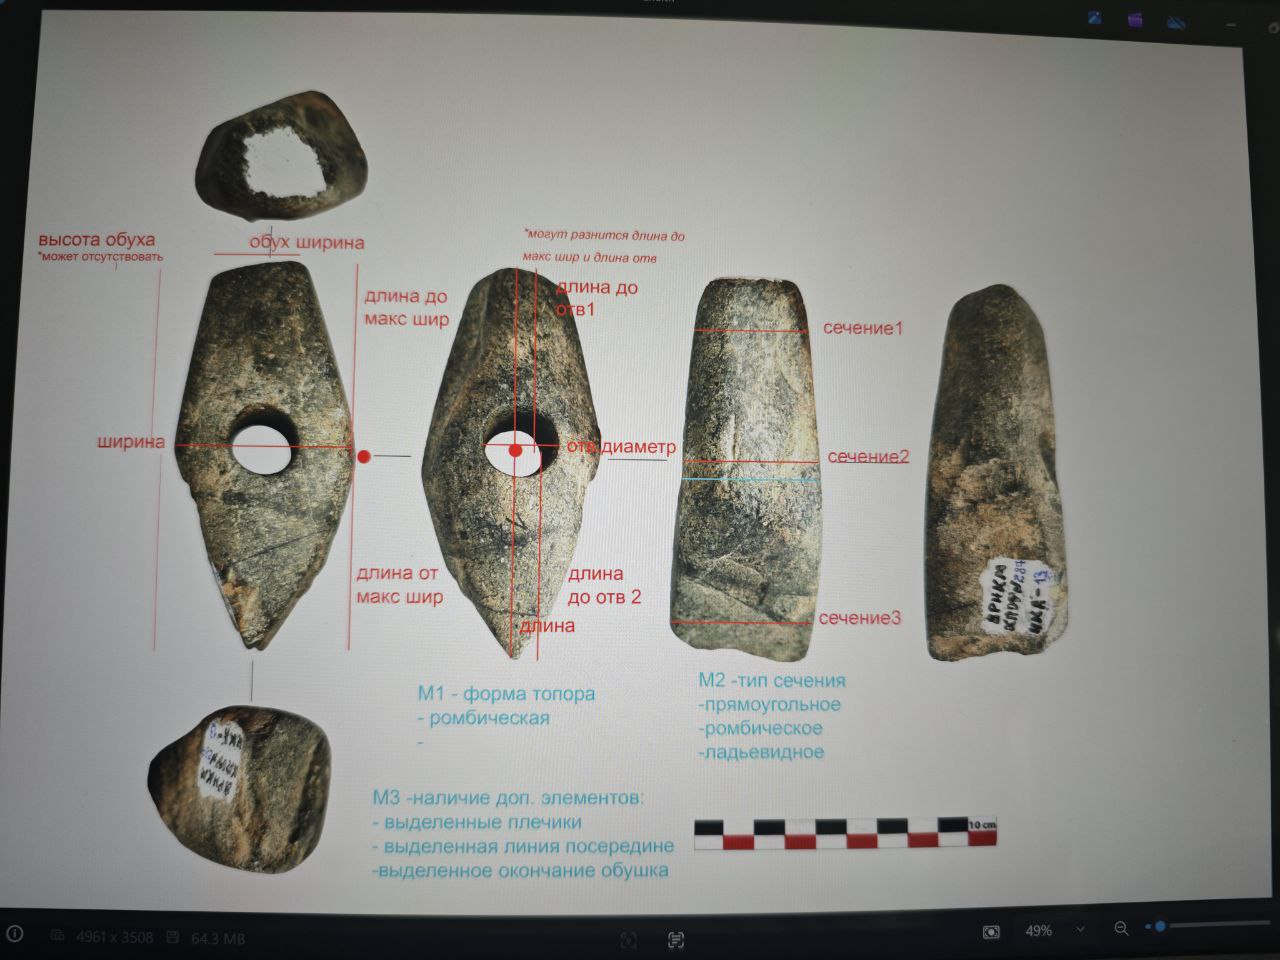

In [ ]:
!pip install --upgrade numpy

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

# Cтарый тип


In [ ]:
df = pd.read_excel('axes.xlsx', sheet_name='ALL')
df = df.drop(0, axis=0)
df = df.rename(columns={'ТИП': 'ТИП1'})

counts = df['ТИП1'].value_counts()
counts

#df

In [ ]:
cols_to_fix = ['прямоугольное', 'трапециевидное', 'ладьевидное c выделенным окночанием', 'ладьевидное выгнутое целиком', 
               'буханочка', 'выделенные плечики', 'выделенная линия посередине', 'выделенно еотверстие возвыша.щееся']

cols_to_fix_1 = ['длина до отв 1', 'сечение 1']

for col in cols_to_fix:
    df[col] = df[col].fillna(0).astype(int)

for col in cols_to_fix_1:
    df[col] = df[col].astype(float)

df['наличие'] = np.where(df['наличие'] == 'да', 1, 0)

df = df.rename(columns={'выделенно еотверстие возвыша.щееся': 'выделенное отверстие возвышающееся'})

df = df[(~df['ТИП1'].isin(['аморфный', 'Iне обработ', 'VI', 'башмачная колодка']))]


In [ ]:
df_1 = df['ТИП1'].str.extract(r'(?P<ТИП1>[IVX]+).(?P<ТИП2>\d)', expand=False)

df_1.fillna({'ТИП1' : df['ТИП1'], 'ТИП2' : 0}, inplace = True)

df['ТИП1'] = df_1['ТИП1']
df['ТИП2'] = df_1['ТИП2']

df = df.iloc[:, np.r_[0, 1, 2, 24, 3:24]]

df['ТИП1'] = df['ТИП1'].astype('category')
df['ТИП2'] = df['ТИП2'].astype('category')

del df_1

df = df.rename(columns={'ТИП1': 'тип1', 'ТИП2': 'тип2'})

#df

## DataFrame с непрерывными признаками

In [ ]:
good_names = [
    'тип1', 'тип2', 'длина_1', 'длина_2', 
    'длина_целого', 'длина_до_макс', 'длина_от_макс', 
    'высота_обуха', 'ширина', 'обух_ширина', 'диаметр', 
    'сечение_1', 'сечение_2', 'сечение_3'
]

df_measurements = df.iloc[:, np.r_[2:16]].copy()
df_measurements.columns = good_names


#print(df_measurements.shape)
df_measurements

In [ ]:
df_measurements.drop(['тип1', 'тип2'], axis=1).describe()

## DataFrame для обучения

In [ ]:
df_for_fit = df_measurements.drop(['тип1', 'тип2'], axis=1)

df_for_fit

In [ ]:
scaler = StandardScaler()
df_for_fit_1 = pd.DataFrame(data = scaler.fit_transform(df_for_fit),
 columns = df_for_fit.columns)

df_for_fit_1

## DataFrame с категориальными признаками

In [ ]:
good_names_1 = ['длина_1', 'длина_2', 
    'длина_целого', 'длина_до_макс', 'длина_от_макс', 'высота_обуха', 'ширина', 'обух_ширина', 'диаметр', 
    'сечение_1', 'сечение_2', 'сечение_3', 'прямоугольное', 'трапециевидное', 'ладьевид.c_выдел.окноч.', 
    'ладьевид.выгнут.целиком', 'буханочка', 'выдел-е_плечики', 'выдел-я_линия_посеред.', 
    'выдел-е_отверст.возвышающееся'
]

In [ ]:
df_with_cat = df.iloc[:, np.r_[4:24]].copy()
df_with_cat.columns = good_names_1
df_with_cat

In [ ]:
# для старой классификации
names = ['тип1', 'тип2']

# Новый тип

In [2]:
df = pd.read_excel('axes.xlsx', sheet_name='sorted')

df_1 = df['id'].str.extract(r't(?P<id>\d+)', expand=False)
df['id'] = df_1.fillna(0).astype(int)

del df_1

df = df.sort_values(by = 'id')
df = df[~(df['новый тип'].isna())]

counts = df['новый тип'].value_counts()
counts

новый тип
1.3                  20
1.1.                 19
1.2                  18
2.3                  14
4.2                   9
4.1                   8
1.4                   7
2.1                   7
3доп                  6
3.2                   5
2.2                   5
3.1                   3
аморфный              2
башмачная колодка     1
Name: count, dtype: int64

In [3]:
df_0 = df.iloc[ : , np.r_[0:3, 4, 7:17, 25:34]]

cols_to_fix = ['прямоугольное', 'трапециевидное', 'ладьевидное c выделенным окночанием', 'ладьевидное выгнутое целиком', 
               'буханочка', 'выделенные плечики', 'выделенная линия посередине', 'выделенно еотверстие возвыша.щееся']

cols_to_fix_1 = ['длина до отв 1', 'сечение 1']

for col in cols_to_fix:
    df_0[col] = df_0[col].fillna(0).astype(int)

for col in cols_to_fix_1:
    df_0[col] = df_0[col].astype(float)

df_0['наличие'] = np.where(df['наличие'] == 'да', 1, 0)

df_0 = df_0.rename(columns={'выделенно еотверстие возвыша.щееся': 'выделенное отверстие возвышающееся'})

df_0 = df_0[(~df_0['новый тип'].isin(['аморфный','башмачная колодка']))]


In [4]:
df_1 = df_0['новый тип'].astype('str').str.extract(r'(?P<новый_тип1>\d).(?P<новый_тип2>\d)', expand=False)

df_1.fillna({'новый_тип1' : df_0['новый тип'], 'новый_тип2' : 0}, inplace = True)

df_0['новый_тип1'] = df_1['новый_тип1']
df_0['новый_тип2'] = df_1['новый_тип2']

del df_1

df_0['новый_тип1'] = df_0['новый_тип1'].astype('category')
df_0['новый_тип2'] = df_0['новый_тип2'].astype('category')

df_0 = df_0.iloc[:, np.r_[0:3, 23, 24, 4:23]]

#df_0

## DataFrame к непрерывными признаками

In [5]:
good_names = ['новый_тип1', 'новый_тип2', 'длина_1', 'длина_2', 
    'длина_целого', 'высота_обуха', 'ширина', 'обух_ширина', 'диаметр', 
    'сечение_1', 'сечение_2', 'сечение_3'
]

df_measurements = df_0.iloc[:, np.r_[3:15]].copy()
df_measurements.columns = good_names

df_measurements['новый_тип1'] = np.where(df_measurements['новый_тип1'] == '3доп', '3', df_measurements['новый_тип1'])
#print(df_measurements.shape)
df_measurements

,новый_тип1,новый_тип2,длина_1,длина_2,длина_целого,высота_обуха,ширина,обух_ширина,диаметр,сечение_1,сечение_2,сечение_3
43,3,0,5.7,8.0,13.7,0.001,6.70,3.40,2.80,3.60,4.90,4.70
44,1,4,5.9,5.2,11.1,0.001,5.00,1.50,2.30,2.80,3.70,3.40
22,4,2,4.2,12.8,17.0,0.001,6.50,5.80,2.90,5.10,5.50,5.10
45,4,2,3.4,6.7,10.1,0.001,4.40,2.70,2.30,3.10,3.80,4.10
46,1,3,6.3,6.4,12.7,0.001,5.90,3.00,1.90,3.30,4.20,4.90
...,...,...,...,...,...,...,...,...,...,...,...,...
121,1,4,6.4,4.9,11.3,3.700,6.15,3.00,2.50,3.36,4.40,4.63
122,1,2,5.1,6.0,11.1,2.800,5.37,2.80,2.20,4.00,4.33,4.40
124,1,2,5.8,7.6,13.4,2.900,6.39,3.94,2.90,4.30,4.46,4.20
20,1,2,6.1,8.4,14.5,0.001,6.88,4.20,2.80,4.82,5.27,5.20


In [6]:
df_measurements.drop(['новый_тип1', 'новый_тип2'], axis=1).describe()

,длина_1,длина_2,длина_целого,высота_обуха,ширина,обух_ширина,диаметр,сечение_1,сечение_2,сечение_3
count,121.000000,121.000000,121.000000,121.000000,121.000000,121.000000,121.000000,121.000000,121.000000,121.000000
mean,5.528099,8.161157,13.704876,1.515388,6.048843,3.161785,2.515702,3.734959,4.468430,4.397851
std,1.456950,2.195388,2.898812,1.718782,1.036329,1.171485,0.378563,1.001190,0.979607,0.942936
min,2.800000,4.100000,8.200000,0.001000,3.380000,0.001000,1.400000,1.720000,2.100000,2.050000
25%,4.500000,6.600000,11.600000,0.001000,5.360000,2.800000,2.290000,3.140000,3.820000,3.880000
50%,5.400000,7.900000,13.400000,0.001000,5.900000,3.200000,2.500000,3.610000,4.330000,4.380000
75%,6.200000,9.300000,15.200000,3.000000,6.580000,3.800000,2.790000,4.200000,5.000000,5.000000
max,12.200000,16.700000,24.500000,6.000000,9.800000,6.350000,3.520000,8.200000,9.000000,9.200000


## DataFrame для обучения

In [7]:
df_for_fit = df_measurements.drop(['новый_тип1', 'новый_тип2'], axis=1)

#df_for_fit

In [8]:
df_for_fit.to_csv('axes_measure.csv')

In [9]:
scaler = StandardScaler()
df_for_fit_1 = pd.DataFrame(data = scaler.fit_transform(df_for_fit),
 columns = df_for_fit.columns)

#df_for_fit_1

In [10]:
df_for_fit_1[['длина_1', 'длина_2', 'высота_обуха', 'ширина', 'обух_ширина', 'диаметр', 'сечение_2']].to_csv('axes_measure.csv')

## DataFrame с категориальными признаками

In [11]:
good_names_1 = ['длина_1', 'длина_2', 
    'длина_целого', 'высота_обуха', 'ширина', 'обух_ширина', 'диаметр', 
    'сечение_1', 'сечение_2', 'сечение_3', 'прямоугольное', 'трапециевидное', 'ладьевид.c_выдел.окноч.', 
    'ладьевид.выгнут.целиком', 'буханочка', 'выдел-е_плечики', 'выдел-я_линия_посеред.', 
    'выдел-е_отверст.возвышающееся'
]

In [12]:
df_with_cat = df_0.iloc[:, np.r_[5:20, 21:24]].copy()
df_with_cat.columns = good_names_1
df_with_cat

,длина_1,длина_2,длина_целого,высота_обуха,ширина,обух_ширина,диаметр,сечение_1,сечение_2,сечение_3,прямоугольное,трапециевидное,ладьевид.c_выдел.окноч.,ладьевид.выгнут.целиком,буханочка,выдел-е_плечики,выдел-я_линия_посеред.,выдел-е_отверст.возвышающееся
43,5.7,8.0,13.7,0.001,6.70,3.40,2.80,3.60,4.90,4.70,0,1,0,0,0,0,1,0
44,5.9,5.2,11.1,0.001,5.00,1.50,2.30,2.80,3.70,3.40,0,0,0,1,0,1,0,0
22,4.2,12.8,17.0,0.001,6.50,5.80,2.90,5.10,5.50,5.10,1,0,0,0,0,0,0,0
45,3.4,6.7,10.1,0.001,4.40,2.70,2.30,3.10,3.80,4.10,0,1,0,0,0,0,0,0
46,6.3,6.4,12.7,0.001,5.90,3.00,1.90,3.30,4.20,4.90,0,1,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
121,6.4,4.9,11.3,3.700,6.15,3.00,2.50,3.36,4.40,4.63,0,1,0,0,0,1,0,1
122,5.1,6.0,11.1,2.800,5.37,2.80,2.20,4.00,4.33,4.40,1,0,0,0,0,0,0,0
124,5.8,7.6,13.4,2.900,6.39,3.94,2.90,4.30,4.46,4.20,1,0,0,0,0,0,0,0
20,6.1,8.4,14.5,0.001,6.88,4.20,2.80,4.82,5.27,5.20,1,0,0,0,0,0,0,0


In [13]:
# для новой классификации
names = ['новый_тип1', 'новый_тип2']

# 1 задание

In [18]:
from sklearn.decomposition import PCA

## Ковариационный PCA


In [19]:
pca_all = PCA().fit(df_for_fit[['длина_1', 'длина_2', 'высота_обуха', 'ширина', 'обух_ширина', 'диаметр', 'сечение_2']])
pc_names = [f'PC{i+1}' for i in range(pca_all.n_components_)]

loadings = pd.DataFrame(
    pca_all.components_.T,           # Транспонируем матрицу весов
    columns=pc_names,                # Столбцы — это компоненты
    index= df_for_fit[['длина_1', 'длина_2', 'высота_обуха', 'ширина', 'обух_ширина', 'диаметр', 'сечение_2']].columns        # Строки — это исходные признаки
)
bins = [-1, -0.6, -0.3, -0.05, 0.05, 0.3, 0.6, 1]
labels = ['---','--','-','0', '+', '++', '+++']
df_signs = loadings.apply(lambda x: pd.cut(x, bins=bins, labels=labels))
df_signs

,PC1,PC2,PC3,PC4,PC5,PC6,PC7
длина_1,+,++,+++,0,++,--,-
длина_2,+++,--,-,--,0,-,0
высота_обуха,++,+++,--,0,-,0,0
ширина,+,0,++,++,-,+++,-
обух_ширина,+,-,--,+++,+++,0,-
диаметр,0,0,0,+,0,0,+++
сечение_2,+,-,+,++,--,--,-


In [20]:
pca3D = PCA(n_components=3)

#dimensions
pca_3D = pca3D.fit_transform(df_for_fit[['длина_1', 'длина_2', 'высота_обуха', 'ширина', 'обух_ширина', 'диаметр', 'сечение_2']])

pca3D_df = pd.DataFrame(data = pca_3D, columns = ['PC1 (X)', 'PC2 (Y)', 'PC3 (Z)'])

pca3D_df[names] = df_measurements[names ]

In [21]:
px.scatter(pca3D_df, 
           x='PC2 (Y)', 
           y='PC3 (Z)', 
           color = names[0], 
           symbol= names[1],
           title = 'PCA_cov',
           width = 1024,
           height = 768
           )

In [22]:
fig = px.scatter_3d(
    pca3D_df,
    x='PC1 (X)',
    y='PC2 (Y)',
    z='PC3 (Z)',
    color = names[0],
    symbol= names[1],
    title='3D проекция PCA_cov',
    color_discrete_sequence=px.colors.qualitative.Bold, 
    opacity=0.8,
    width = 1024,
    height = 768
)

fig.update_layout(margin=dict(l=0, r=0, b=0, t=50))
fig.update_traces(marker=dict(size=5, line=dict(width=1, color='DarkSlateGrey')))

fig.show()

## Корреляционный PCA

In [ ]:
pca_all_1 = PCA().fit(df_for_fit_1[['длина_1', 'длина_2', 'высота_обуха', 'ширина', 'обух_ширина', 'диаметр', 'сечение_2']])
pc_names = [f'PC{i+1}' for i in range(pca_all_1.n_components_)]
loadings_1 = pd.DataFrame(
    pca_all_1.components_.T,         # Транспонируем матрицу весов
    columns=pc_names,                # Столбцы — это компоненты
    index=df_for_fit_1[['длина_1', 'длина_2', 'высота_обуха', 'ширина', 'обух_ширина', 'диаметр', 'сечение_2']].columns       # Строки — это исходные признаки
)

bins = [-1, -0.6, -0.3, -0.05, 0.05, 0.3, 0.6, 1]
labels = ['---','--','-','0', '+', '++', '+++']
df_signs_1 = loadings_1.apply(lambda x: pd.cut(x, bins=bins, labels=labels))
df_signs_1

In [ ]:
pca3D_1 = PCA(n_components=3)

#dimensions
pca_3D_1 = pca3D_1.fit_transform(df_for_fit_1[['длина_1', 'длина_2', 'высота_обуха', 'ширина', 'обух_ширина', 'диаметр', 'сечение_2']])
pca3D_df_1 = pd.DataFrame(data = pca_3D_1, columns = ['PC1 (X)', 'PC2 (Y)', 'PC3 (Z)'])

pca3D_df_1[names] = df_measurements[names]

px.scatter(pca3D_df_1, 
           x='PC2 (Y)', 
           y='PC3 (Z)', 
           color = names[0],
           symbol= names[1],
           title = 'PCA_corr',
           width = 1024,
           height = 768
           )


In [ ]:
fig = px.scatter_3d(
    pca3D_df_1,
    x='PC1 (X)',
    y='PC2 (Y)',
    z='PC3 (Z)',
    color = names[0],
    symbol= names[1],
    title='3D проекция PCA_corr',
    color_discrete_sequence=px.colors.qualitative.Bold, 
    opacity=0.8,
    width = 1024,
    height = 768
)

fig.update_layout(margin=dict(l=0, r=0, b=0, t=50))
fig.update_traces(marker=dict(size=5, line=dict(width=1, color='DarkSlateGrey')))

fig.show()

## Matrix plot

<Axes: >

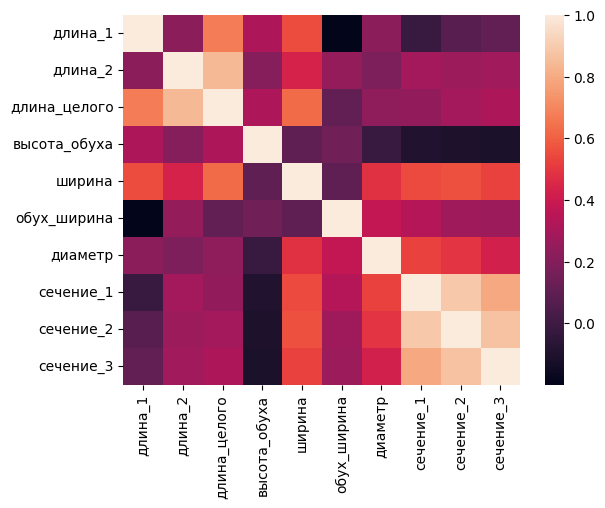

In [26]:
corr = df_for_fit_1.corr()
sns.heatmap(corr)

scatterplot для ['длина_1', 'длина_2', 'высота_обуха', 'ширина', 'обух_ширина', 'диаметр', 'сечение_2']

In [27]:
df_matrix = df_measurements.copy()
# Создаём колонку с объединённым текстом для hover
df_matrix['тип1_тип2'] = df_matrix['новый_тип1'].astype(str) + ' - ' + df_matrix['новый_тип2'].astype(str)

# Строим scatter matrix
fig = px.scatter_matrix(
    df_matrix,
    dimensions=['длина_1', 'длина_2', 'высота_обуха', 'ширина',
                'обух_ширина', 'диаметр', 'сечение_2'],
    color = names[0],                # дискретные цвета по типу1
    symbol= names[1],                # форма по типу2
    hover_name='тип1_тип2',       # текст при наведении (будет жирным заголовком)
    title='Scatterplot'
)

# Скрываем диагональные графики (гистограммы)
fig.update_traces(diagonal_visible=False)

# Настраиваем внешний вид маркеров (белая обводка, как в оригинале)
fig.update_traces(marker=dict(line=dict(color='white', width=0.5)))

# Задаём размер фигуры
fig.update_layout(width=1536, height=1536)

fig.show()

del df_matrix

откинуть 4, 5, сечение 1 и 3

## Покоординатные boxplot+violin 

In [ ]:
df_measurements_1 = df_measurements[(df_measurements[names[0]] != 'аморфный')&(df_measurements[names[0]] != 'башмачная колодка')
#&(df_measurements[names[0]] != 'Iне обработ')&(df_measurements[names[0]] != 'VI') # для старой классификации
]

In [ ]:
import plotly.graph_objects as go

fig = go.Figure()

# 1. Добавляем Violin plot (скрипичная диаграмма)
fig.add_trace(go.Violin(
    x=df_measurements_1[names[0]],        # <-- СТОЛБЕЦ С КАТЕГОРИЯМИ
    y=df_measurements_1['длина_1'],     # <-- СТОЛБЕЦ СО ЗНАЧЕНИЯМИ
    box_visible=True,          # Показывать boxplot внутри
    meanline_visible=True,     # Показывать линию среднего
    #points='all',              # Показывать все точки: 'all', 'outliers', 'suspectedoutliers', False
    side='both',               # Расположение: 'both', 'positive', 'negative'
    width=0.8,                 # Ширина скрипки (0-1)
    fillcolor='lightblue',     # Цвет заливки
    line_color='blue',         # Цвет линий
    opacity=0.6                # Прозрачность
))

fig.update_layout(
    # РАЗМЕР РИСУНКА
    width=1400,      # Ширина в пикселях
    height=900,      # Высота в пикселях
    autosize=False,  # Отключаем авторазмер
    
    # МАРЖИНЫ (отступы)
    margin=dict(
        l=100,  # отступ слева (left)
        r=100,  # отступ справа (right)
        t=100,  # отступ сверху (top)
        b=100   # отступ снизу (bottom)
    ),
    
    # ДОПОЛНИТЕЛЬНЫЕ НАСТРОЙКИ ДЛЯ УВЕЛИЧЕНИЯ
    title=dict(
        text= 'Violin plot for lenth 1',
        font=dict(size=24)  # Увеличиваем шрифт заголовка
    ),
    font=dict(size=14),  # Увеличиваем все шрифты
    
    # Размер осей
    xaxis=dict(
        title=dict(
            text='Категории',
            font=dict(size=18)
        ),
        tickfont=dict(size=14)
    ),
    yaxis=dict(
        title=dict(
            text='Значения',
            font=dict(size=18)
        ),
        tickfont=dict(size=14)
    )
)

fig.show()

In [ ]:
import plotly.graph_objects as go

fig = go.Figure()

# 1. Добавляем Violin plot (скрипичная диаграмма)
fig.add_trace(go.Violin(
    x=df_measurements_1[names[0]],        # <-- СТОЛБЕЦ С КАТЕГОРИЯМИ
    y=df_measurements_1['длина_2'],     # <-- СТОЛБЕЦ СО ЗНАЧЕНИЯМИ
    box_visible=True,          # Показывать boxplot внутри
    meanline_visible=True,     # Показывать линию среднего
    #points='all',              # Показывать все точки: 'all', 'outliers', 'suspectedoutliers', False
    side='both',               # Расположение: 'both', 'positive', 'negative'
    width=0.8,                 # Ширина скрипки (0-1)
    fillcolor='lightblue',     # Цвет заливки
    line_color='blue',         # Цвет линий
    opacity=0.6                # Прозрачность
))

fig.update_layout(
    # РАЗМЕР РИСУНКА
    width=1400,      # Ширина в пикселях
    height=900,      # Высота в пикселях
    autosize=False,  # Отключаем авторазмер
    
    # МАРЖИНЫ (отступы)
    margin=dict(
        l=100,  # отступ слева (left)
        r=100,  # отступ справа (right)
        t=100,  # отступ сверху (top)
        b=100   # отступ снизу (bottom)
    ),
    
    # ДОПОЛНИТЕЛЬНЫЕ НАСТРОЙКИ ДЛЯ УВЕЛИЧЕНИЯ
    title=dict(
        text= 'Violin plot for lenth 2',
        font=dict(size=24)  # Увеличиваем шрифт заголовка
    ),
    font=dict(size=14),  # Увеличиваем все шрифты
    
    # Размер осей
    xaxis=dict(
        title=dict(
            text='Категории',
            font=dict(size=18)
        ),
        tickfont=dict(size=14)
    ),
    yaxis=dict(
        title=dict(
            text='Значения',
            font=dict(size=18)
        ),
        tickfont=dict(size=14)
    )
)

fig.show()

## Избавление от размера в данных (нормирование векторов)
Не помогает

In [ ]:
from sklearn.preprocessing import normalize

df_for_fit_norm = pd.DataFrame(normalize(df_for_fit, axis=1, norm='l2'), columns=df_for_fit.columns)

#df_for_fit_norm

In [ ]:
df_for_fit_norm_1 = pd.DataFrame(data = scaler.fit_transform(df_for_fit_norm),
 columns = df_for_fit.columns)
#df_for_fit_1.shape

In [ ]:
pca_all_norm = PCA().fit(df_for_fit_norm_1)
pc_names = [f'PC{i+1}' for i in range(pca_all_norm.n_components_)]
loadings_1 = pd.DataFrame(
    pca_all_norm.components_.T,         # Транспонируем матрицу весов
    columns = pc_names,              # Столбцы — это компоненты
    index = df_for_fit.columns       # Строки — это исходные признаки
)

bins = [-1, -0.6, -0.3, -0.05, 0.05, 0.3, 0.6, 1]
labels = ['---','--','-','0', '+', '++', '+++']
df_signs_1 = loadings_1.apply(lambda x: pd.cut(x, bins=bins, labels=labels))
df_signs_1

In [ ]:
pca3D_1 = PCA(n_components=3)

#dimensions
pca_3D_1 = pca3D_1.fit_transform(df_for_fit_norm_1)
pca3D_df_1 = pd.DataFrame(data = pca_3D_1, columns = ['PC1 (X)', 'PC2 (Y)', 'PC3 (Z)'])

pca3D_df_1[['новый_тип1', 'новый_тип2']] = df_measurements[['новый_тип1', 'новый_тип2']]

px.scatter(pca3D_df_1, 
           x='PC1 (X)', 
           y='PC2 (Y)', 
           color = 'новый_тип1', 
           symbol='новый_тип2',
           title = 'PCA_corr',
           width = 1024,
           height = 768
           )

In [ ]:
fig = px.scatter_3d(
    pca3D_df_1,
    x='PC1 (X)',
    y='PC2 (Y)',
    z='PC3 (Z)',
    color='новый_тип1',
    symbol='новый_тип2',
    title='3D проекция PCA_corr',
    color_discrete_sequence=px.colors.qualitative.Bold, 
    opacity=0.8,
    width = 1024,
    height = 768
)

fig.update_layout(margin=dict(l=0, r=0, b=0, t=50))
fig.update_traces(marker=dict(size=5, line=dict(width=1, color='DarkSlateGrey')))

fig.show()

# Другие методы уменьшения размерности данных


## Independent Computing Architecture (ICA)

In [ ]:
from sklearn.decomposition import FastICA

ica3D = FastICA(n_components=3)
ica_data3D = ica3D.fit_transform(df_for_fit_1)
ica3D_df = pd.DataFrame(data =  ica_data3D, columns = ['C1 (X)', 'C2 (Y)', 'C3 (Z)'])

ica3D_df[['новый_тип1', 'новый_тип2']] = df_measurements[['новый_тип1', 'новый_тип2']]


In [ ]:
px.scatter(ica3D_df, 
           x='C1 (X)', 
           y='C2 (Y)', 
           color = 'новый_тип1', 
           symbol='новый_тип2',
           title = 'ICA',
           width = 1024,
           height = 768
           )

In [ ]:
fig = px.scatter_3d(
    ica3D_df, 
    x='C1 (X)', 
    y='C2 (Y)', 
    z='C3 (Z)',
    color='новый_тип1',
    symbol='новый_тип2',
    title='3D проекция ICA',
    color_discrete_sequence=px.colors.qualitative.Bold, 
    opacity=0.8,
    width = 1024,
    height = 768
)

fig.update_layout(margin=dict(l=0, r=0, b=0, t=50))
fig.update_traces(marker=dict(size=5, line=dict(width=1, color='DarkSlateGrey')))

fig.show()

## Uniform Manifold Approximation and Projection (UMAP)

In [ ]:
from umap.umap_ import UMAP

umap3D = UMAP(n_components=3)
umap_data3D = umap3D.fit_transform(df_for_fit_1)
umap3D_df = pd.DataFrame(data =  umap_data3D,columns = ['C1 (X)', 'C2 (Y)', 'C3 (Z)'])

umap3D_df[['новый_тип1', 'новый_тип2']] = df_measurements[['новый_тип1', 'новый_тип2']]

In [ ]:
px.scatter(umap3D_df, 
           x='C1 (X)', 
           y='C2 (Y)', 
           color = 'новый_тип1', 
           symbol='новый_тип2',
           title = 'UMAP',
           width = 1024,
           height = 768
           )

In [ ]:
fig = px.scatter_3d(
    umap3D_df, 
    x='C1 (X)', 
    y='C2 (Y)', 
    z='C3 (Z)',
    color='новый_тип1',
    symbol='новый_тип2',
    title='3D проекция UMAP',
    color_discrete_sequence=px.colors.qualitative.Bold, 
    opacity=0.8,
    width = 1024,
    height = 768
)

fig.update_layout(margin=dict(l=0, r=0, b=0, t=50))
fig.update_traces(marker=dict(size=5, line=dict(width=1, color='DarkSlateGrey')))

fig.show()

## t-Distributed Stochastic Neighbor Embedding (t-SNE)

In [ ]:
from sklearn.manifold import TSNE

tsne3D = TSNE(n_components=3)
tsne_data3D = tsne3D.fit_transform(df_for_fit_1)
tsne3D_df = pd.DataFrame(data =  tsne_data3D, columns = ['C1 (X)', 'C2 (Y)', 'C3 (Z)'])

tsne3D_df[['новый_тип1', 'новый_тип2']] = df_measurements[['новый_тип1', 'новый_тип2']]

In [ ]:
px.scatter(tsne3D_df, 
           x='C1 (X)', 
           y='C2 (Y)', 
           color = 'новый_тип1', 
           symbol='новый_тип2',
           title = 't-SNE',
           width = 1024,
           height = 768
           )

In [ ]:
fig = px.scatter_3d(
    tsne3D_df, 
    x='C1 (X)', 
    y='C2 (Y)', 
    z='C3 (Z)',
    color='новый_тип1',
    symbol='новый_тип2',
    title='3D проекция t-SNE',
    color_discrete_sequence=px.colors.qualitative.Bold, 
    opacity=0.8,
    width = 1024,
    height = 768
)

fig.update_layout(margin=dict(l=0, r=0, b=0, t=50))
fig.update_traces(marker=dict(size=5, line=dict(width=1, color='DarkSlateGrey')))

fig.show()

# Linear Discriminant Analysis (LDA)

In [12]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

In [ ]:
#для старой классификации
df_lda = df_measurements.drop(names[1], axis=1)[(df_measurements[names[0]].isin(['I', 'VIII', 'II']))]
df_lda_fit = pd.DataFrame(data = scaler.fit_transform(df_lda.drop([names[0]], axis=1)), columns = df_for_fit.columns)
df_lda_fit

In [ ]:
# для новой классификации
df_lda = df_measurements.drop(names[1], axis=1)[(df_measurements[names[0]].isin(['1', '2', '4']))]
df_lda_fit = pd.DataFrame(data = scaler.fit_transform(df_lda.drop([names[0]], axis=1)), columns = df_for_fit.columns)
df_lda_fit

In [ ]:
encoder = LabelEncoder()
X1, y = df_lda_fit[['длина_1', 'длина_2', 'высота_обуха', 'ширина', 'обух_ширина', 'диаметр', 'сечение_2']], df_lda[names[0]]

X1, y1 = X1.values, encoder.fit_transform(y)
mapping = {label: i for i, label in enumerate(encoder.classes_)}
print(mapping)
X1_train, X1_test, y1_train, y1_test = train_test_split(X1, y1, random_state=42)


In [ ]:
sk_lda = LinearDiscriminantAnalysis(solver='eigen')
sk_lda.fit(X1_train, y1_train)
sk_lda_pred_res = sk_lda.predict(X1_test)
sk_transformed = sk_lda.transform(X1_train)
sk_lda_accuracy = accuracy_score(y1_test, sk_lda_pred_res)

print(f'LDA accuracy: {sk_lda_accuracy}')
print(f'LDA prediction: {sk_lda_pred_res}')
print('Transformed features', sk_transformed[:5].T, sep='\n')



## 2 и более класса

In [ ]:
ld1_class0 = sk_transformed[y1_train == 0, 0]
ld1_class1 = sk_transformed[y1_train == 1, 0]

plt.hist(ld1_class0, bins=20, alpha=0.5, label='Class 0', density=False)
plt.hist(ld1_class1, bins=20, alpha=0.5, label='Class 1', density=False)
plt.xlabel('LD1')
plt.ylabel('Частота')
plt.legend()
plt.title('Распределение проекций на первую дискриминантную ось')
plt.show()

## 3 и более классов

In [ ]:
X1_lda_full = sk_lda.transform(X1)  # X1 - полный набор признаков
lda2D_df = pd.DataFrame(data=X1_lda_full[:, :2], columns=['LD1 (X)', 'LD2 (Y)'])
lda2D_df['тип1'] = y1  # полные метки

In [ ]:
# Визуализация с классификатором

from matplotlib.colors import ListedColormap

clf_lda2 = LinearDiscriminantAnalysis()
X2D = X1_lda_full[:, :2]
clf_lda2.fit(X2D, y1)

# 1. Настраиваем сетку (meshgrid)
# Определяем минимальные и максимальные значения по осям с небольшим отступом
x_min, x_max = X2D[:, 0].min() - 1, X2D[:, 0].max() + 1
y_min, y_max = X2D[:, 1].min() - 1, X2D[:, 1].max() + 1

# Шаг сетки (чем меньше, тем выше разрешение, но дольше считается)
h = 0.02  
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))

Z = clf_lda2.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(8, 6))

# Закрашиваем области решений
# Вы можете задать свои цвета в ListedColormap, если их больше/меньше
cmap_light = ListedColormap(['#FFAAAA', '#AAFFAA', '#AAAAFF'])
cmap_bold = ListedColormap(['#FF0000', '#00FF00', '#0000FF'])

plt.contourf(xx, yy, Z, alpha=0.4, cmap=cmap_light)

# Наносим реальные точки данных
scatter = plt.scatter(X2D[:, 0], X2D[:, 1], c=y1, cmap=cmap_bold, 
                      edgecolors='k', s=40)

# Добавляем легенду, опираясь на метки классов
plt.legend(handles=scatter.legend_elements()[0], 
           labels=list(mapping.keys()), # используем ваш словарь mapping
           title="Классы")

plt.title('LDA decision surface in first two LD components')
plt.xlabel('LD1')
plt.ylabel('LD2')
plt.show()

In [ ]:
# визуализация без классификатора
fig = px.scatter(lda2D_df, 
                 x='LD1 (X)', 
                 y='LD2 (Y)', 
                 color='тип1', 
                 title='LDA',
                 width = 768,
                 height = 768
                 )

fig.update_layout(coloraxis_showscale=False)

fig.show()

## 4 и более классов

In [ ]:
X1_lda_full = sk_lda.transform(X1)  # X1 - полный набор признаков
lda3D_df = pd.DataFrame(data=X1_lda_full[:, :3], columns=['LD1 (X)', 'LD2 (Y)', 'LD3 (Z)'])
lda3D_df['тип1'] = y1  # полные метки


fig = px.scatter_3d(
    lda3D_df,
    x='LD1 (X)',
    y='LD2 (Y)',
    z='LD3 (Z)',
    color='тип1',
    title='3D проекция LDA',
    color_discrete_sequence=px.colors.qualitative.Bold, 
    opacity=0.8,
    width = 1024,
    height = 768
)

fig.update_layout(margin=dict(l=0, r=0, b=0, t=50), coloraxis_showscale=False)
fig.update_traces(marker=dict(size=5, line=dict(width=1, color='DarkSlateGrey')))

fig.show()

# Quadratic Discriminant Analysis (QDA)

In [62]:
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from matplotlib import colors
from sklearn.inspection import DecisionBoundaryDisplay

In [65]:
df_qda = df_measurements.drop(names[1], axis=1)[(df_measurements[names[0]].isin(['1', '2', '3']))]
df_qda_fit = pd.DataFrame(data = scaler.fit_transform(df_qda.drop([names[0]], axis=1)), columns = df_for_fit.columns)
df_qda_fit

,длина_1,длина_2,длина_целого,высота_обуха,ширина,обух_ширина,диаметр,сечение_1,сечение_2,сечение_3
0,0.026808,0.048339,0.042922,-1.021939,0.806427,0.323048,0.830178,0.013448,0.592918,0.412822
1,0.162810,-1.279620,-0.847809,-1.021939,-1.029477,-1.660185,-0.548591,-0.881659,-0.708914,-1.000894
2,0.434813,-0.710495,-0.299667,-1.021939,-0.057528,-0.094475,-1.651606,-0.322217,-0.166484,0.630316
3,0.162810,-0.805349,-0.505220,-1.021939,0.190859,0.563124,0.278670,1.579885,1.428260,1.239301
4,-1.469209,-1.137339,-1.567246,0.137501,-1.061876,0.124725,0.554424,0.684778,0.083034,-0.011293
...,...,...,...,...,...,...,...,...,...,...
99,0.502813,-1.421901,-0.779291,1.123518,0.212458,-0.094475,0.002917,-0.255084,0.050488,0.336698
100,-0.381197,-0.900203,-0.847809,0.601509,-0.629898,-0.303236,-0.824345,0.461002,-0.025452,0.086580
101,0.094809,-0.141369,-0.059854,0.659510,0.471645,0.886704,1.105932,0.796667,0.115579,-0.130915
102,0.298811,0.238048,0.316994,-1.021939,1.000817,1.158094,0.830178,1.378486,0.994316,0.956558


In [66]:
encoder = LabelEncoder()

X = df_qda_fit[['длина_1', 'длина_2', 'высота_обуха', 'ширина', 'обух_ширина', 'диаметр', 'сечение_2']].values
y = encoder.fit_transform(df_qda[names[0]])

mapping = {label: i for i, label in enumerate(encoder.classes_)}
print(mapping)
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

{'1': 0, '2': 1, '3': 2}


In [67]:
sk_qda = QuadraticDiscriminantAnalysis(solver='eigen', shrinkage=0.1, store_covariance=True)
sk_qda.fit(X_train, y_train)

sk_qda_pred_res = sk_qda.predict(X_test)
sk_qda_accuracy = accuracy_score(y_test, sk_qda_pred_res)

print(f'LDA accuracy: {sk_qda_accuracy}')
print(f'LDA prediction: {sk_qda_pred_res}')

LDA accuracy: 0.6538461538461539
LDA prediction: [0 0 0 2 0 0 0 2 0 0 2 1 1 0 0 0 0 1 1 1 0 0 0 0 0 0]


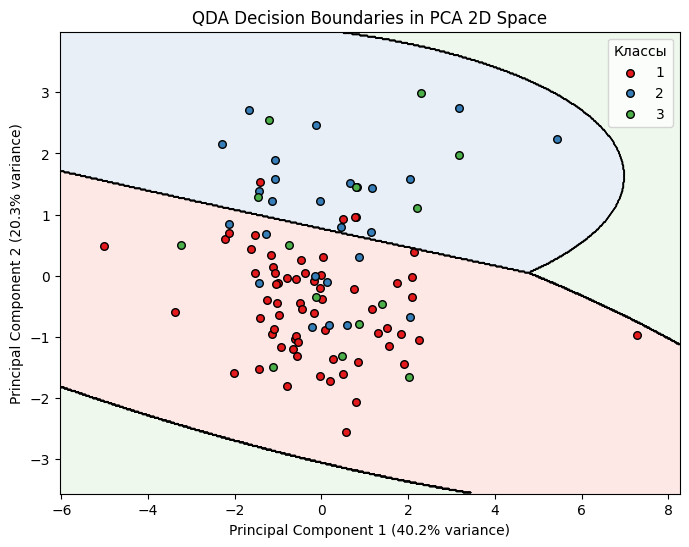

In [68]:
from matplotlib.colors import ListedColormap
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.decomposition import PCA
from sklearn.preprocessing import LabelEncoder, StandardScaler

encoder = LabelEncoder()
feature_cols = ['длина_1', 'длина_2', 'высота_обуха', 'ширина', 'обух_ширина', 'диаметр', 'сечение_2']
X1 = df_qda_fit[feature_cols].values
y = encoder.fit_transform(df_qda[names[0]])

scaler = StandardScaler()
X1_scaled = scaler.fit_transform(X1)

pca = PCA(n_components=2)
X_pca_2d = pca.fit_transform(X1_scaled)

sk_qda_2d = QuadraticDiscriminantAnalysis()
sk_qda_2d.fit(X_pca_2d, y)

x_min, x_max = X_pca_2d[:, 0].min() - 1, X_pca_2d[:, 0].max() + 1
y_min, y_max = X_pca_2d[:, 1].min() - 1, X_pca_2d[:, 1].max() + 1
h = 0.02
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))

Z = sk_qda_2d.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

n_classes = len(encoder.classes_)
cmap_light = ListedColormap(plt.cm.Pastel1.colors[:n_classes])
cmap_bold = plt.cm.Set1.colors[:n_classes]

fig, ax = plt.subplots(figsize=(8, 6))

ax.pcolormesh(xx, yy, Z, alpha=0.3, cmap=cmap_light, shading='auto')
ax.contour(xx, yy, Z, colors='k', linewidths=0.8)

for i, color in enumerate(cmap_bold):
    idx = np.where(y == i)
    ax.scatter(X_pca_2d[idx, 0], X_pca_2d[idx, 1], c=[color], edgecolor='black', s=30, label=encoder.classes_[i])

ax.set_title("QDA Decision Boundaries in PCA 2D Space")
# Добавляем процент объясненной дисперсии в подписи осей
ax.set_xlabel(f"Principal Component 1 ({pca.explained_variance_ratio_[0]:.1%} variance)")
ax.set_ylabel(f"Principal Component 2 ({pca.explained_variance_ratio_[1]:.1%} variance)")
ax.legend(title="Классы")
plt.show()

# Silhouette Plot

5


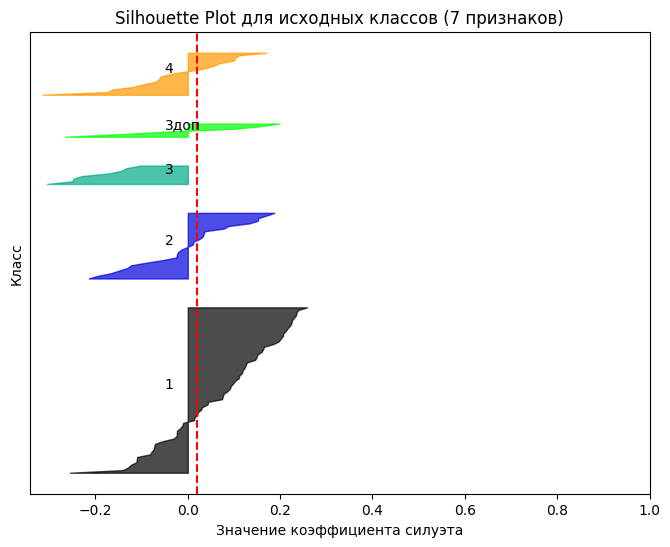

Средний коэффициент силуэта для всего набора данных: 0.019


In [47]:
import matplotlib.cm as cm
from sklearn.metrics import silhouette_samples, silhouette_score

X = df_for_fit_1
y = encoder.fit_transform(df_measurements[names[0]])
n_classes = len(np.unique(y))
print(n_classes)

silhouette_avg = silhouette_score(X, y)
sample_silhouette_values = silhouette_samples(X, y)

fig, ax = plt.subplots(figsize=(8, 6))
y_lower = 10

for i in range(n_classes):
    # Агрегация и сортировка значений для каждого класса
    ith_cluster_silhouette_values = sample_silhouette_values[y == i]
    ith_cluster_silhouette_values.sort()

    size_cluster_i = ith_cluster_silhouette_values.shape[0]
    y_upper = y_lower + size_cluster_i

    color = cm.nipy_spectral(float(i) / n_classes)
    ax.fill_betweenx(np.arange(y_lower, y_upper),
                     0, ith_cluster_silhouette_values,
                     facecolor=color, edgecolor=color, alpha=0.7)

    # Добавление названия класса рядом с его силуэтом
    ax.text(-0.05, y_lower + 0.5 * size_cluster_i, str(encoder.classes_[i]))

    # Отступ перед отрисовкой следующего класса
    y_lower = y_upper + 10

ax.set_title("Silhouette Plot для исходных классов (7 признаков)")
ax.set_xlabel("Значение коэффициента силуэта")
ax.set_ylabel("Класс")

# Отрисовка линии общего среднего значения
ax.axvline(x=silhouette_avg, color="red", linestyle="--")

ax.set_yticks([])
ax.set_xticks(np.arange(-0.2, 1.1, 0.2))

plt.show()

print(f"Средний коэффициент силуэта для всего набора данных: {silhouette_avg:.3f}")

# DBScan

In [15]:
from sklearn.cluster import DBSCAN

X = df_measurements.drop(names, axis=1)[['длина_1', 'длина_2', 'высота_обуха', 'ширина', 'обух_ширина', 'диаметр', 'сечение_2']][(df_measurements[names[0]].isin(['1', '2', '3']))]

dbs = DBSCAN(eps = 1, min_samples = 5)
a = dbs.fit(X)
print(a.labels_)


[-1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1
 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1
 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1
 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1
 -1 -1 -1 -1 -1 -1 -1 -1]


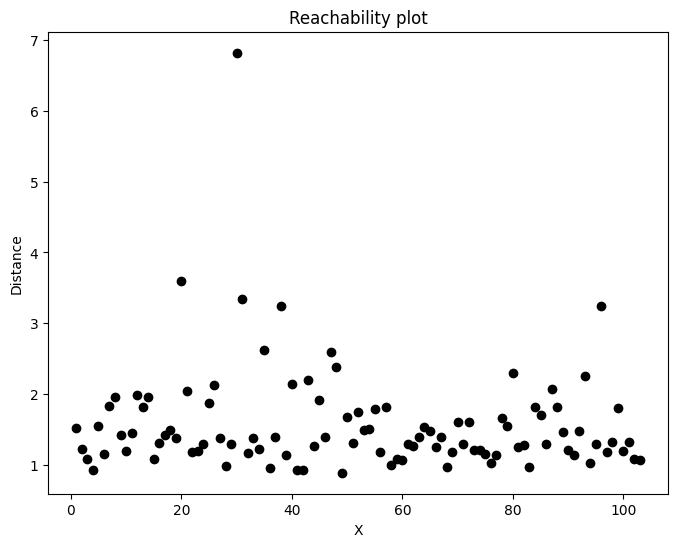

In [16]:
from sklearn.cluster import OPTICS
opt = OPTICS(min_samples = 3)
a = opt.fit(X)

plt.figure(figsize = (8, 6))
plt.scatter(np.arange(len(X['длина_1'])), a.reachability_, color = 'black')
plt.title('Reachability plot')
plt.xlabel('X')
plt.ylabel('Distance')
plt.show()

# Что надо сделать:

# Вопросы: